In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib import image
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon
from matplotlib.patches import Rectangle
import numpy as np
from collections import Counter
from scipy.spatial import cKDTree as KDT
from astropy.table import Column, Table
import itertools
import copy
import scipy.signal
from scipy.spatial import distance
import math
import sys
import pdb
import pickle as pickle
from astropy.convolution import convolve, Gaussian2DKernel
import astropy.coordinates as coord
import astropy.units as u
from astropy.io import ascii
import mpl_scatter_density
from scipy.stats import gaussian_kde, kde
from spisea import synthetic, evolution, atmospheres, reddening, ifmr
from spisea.imf import imf, multiplicity
import pdb
import pylab as py
from flystar import match, transforms, plots, align
from flystar import starlists
from flystar.starlists import StarList
from flystar.startables import StarTable
from astropy.table import Table, Column, vstack
import flystar
import datetime
import copy
import os
import pdb
import time
import warnings
from astropy.utils.exceptions import AstropyUserWarning
from numpy.polynomial.polynomial import polyfit
from astropy.io import fits
from astropy.table import * 
from astropy.modeling import models, fitting

### Extracting Stars from Matched Catalog

In [3]:
fits_image_filename ='catalogs/dr2/jwst_init_NRCB.fits'
t = Table.read(fits_image_filename, format='fits')

def get_all_filts(t):
    """
    Helper function to get filts in a catalog, regardless of
    masking
    """
    nepochs = len(t['filt'][0])

    # Loop through each time entry and get year
    # from a non-masked source
    filt_arr = []
    for ii in range(nepochs):
        filt_col = t['filt'][:,ii]

        good = np.where(t['x'][:,ii].mask == False)[0]
        if len(good) > 0:
            filt_arr.append(t['filt'][good[0],ii])
        else:
            filt_arr.append(np.nan)
       

    filt_arr = np.array(filt_arr)
   
    return filt_arr

def get_all_dets(t): 
    """
    Helper function to get detectors in a catalog, regardless of
    masking
    """
    nepochs = len(t['det'][0])

    # Loop through each time entry and get year
    # from a non-masked source
    det_arr = []
    for ii in range(nepochs):
        det_col = t['det'][:,ii]

        good = np.where(t['x'][:,ii].mask == False)[0]
        if len(good) > 0:
            det_arr.append(t['det'][good[0],ii])
        else:
            det_arr.append(np.nan)

    det_arr = np.array(det_arr)
   
    return det_arr

def get_matches(t, filt1, det1, filt2, det2): 
    filt = get_all_filts(t)
    det = get_all_dets(t)

    idx1 = np.where( (filt == filt1) & (det == det1) ) 
    idx2 = np.where( (filt == filt2) & (det == det2) ) 

    filt_1 = t['m_orig'][:,idx1]
    filt_2 = t['m_orig'][:,idx2]

    filt_1me = t['me_orig'][:,idx1]
    filt_2me = t['me_orig'][:,idx2]
    
    good = np.where( (filt_1.mask == False) & (filt_2.mask == False) )
    m_filt1_match = filt_1[good]
    m_filt2_match = filt_2[good]
    me_filt1_match = filt_1me[good]
    me_filt2_match = filt_2me[good]

    return m_filt1_match, m_filt2_match, me_filt1_match, me_filt2_match

# All NRCBs between F212N and F115W
N1_f115w_vf212n, N1_f212n_vf115w, N1_f115w_vf212n_me, N1_f212n_vf115w_me = get_matches(t, 'F115W', 'NRCB1', 'F212N', 'NRCB1')
N2_f115w_vf212n, N2_f212n_vf115w, N2_f115w_vf212n_me, N2_f212n_vf115w_me = get_matches(t, 'F115W', 'NRCB2', 'F212N', 'NRCB2')
N3_f115w_vf212n, N3_f212n_vf115w, N3_f115w_vf212n_me, N3_f212n_vf115w_me = get_matches(t, 'F115W', 'NRCB3', 'F212N', 'NRCB3')
N4_f115w_vf212n, N4_f212n_vf115w, N4_f115w_vf212n_me, N4_f212n_vf115w_me = get_matches(t, 'F115W', 'NRCB4', 'F212N', 'NRCB4')

# All NRCB1-4 F212N vs. NRCB5 F323N and F405N
N1_f212n_vN5_f323n, N5_f323n_vN1_f212n, N1_f212n_vN5_f323n_me, N5_f323n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB1', 'F323N', 'NRCB5')
N2_f212n_vN5_f323n, N5_f323n_vN2_f212n, N2_f212n_vN5_f323n_me, N5_f323n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB2', 'F323N', 'NRCB5')
N3_f212n_vN5_f323n, N5_f323n_vN3_f212n, N3_f212n_vN5_f323n_me, N5_f323n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB3', 'F323N', 'NRCB5')
N4_f212n_vN5_f323n, N5_f323n_vN4_f212n, N4_f212n_vN5_f323n_me, N5_f323n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB4', 'F323N', 'NRCB5')

N1_f212n_vN5_f405n, N5_f405n_vN1_f212n, N1_f212n_vN5_f405n_me, N5_f405n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB1', 'F405N', 'NRCB5')
N2_f212n_vN5_f405n, N5_f405n_vN2_f212n, N2_f212n_vN5_f405n_me, N5_f405n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB2', 'F405N', 'NRCB5')
N3_f212n_vN5_f405n, N5_f405n_vN3_f212n, N3_f212n_vN5_f405n_me, N5_f405n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB3', 'F405N', 'NRCB5')
N4_f212n_vN5_f405n, N5_f405n_vN4_f212n, N4_f212n_vN5_f405n_me, N5_f405n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB4', 'F405N', 'NRCB5')

N1_f115w_vf212n += 25.92
N2_f115w_vf212n += 25.95
N3_f115w_vf212n += 25.95
N4_f115w_vf212n += 26.09

N1_f212n_vf115w += 22.12
N2_f212n_vf115w += 22.15
N3_f212n_vf115w += 22.15 
N4_f212n_vf115w += 22.23
N1_f212n_vN5_f323n += 22.12
N2_f212n_vN5_f323n += 22.15
N3_f212n_vN5_f323n += 22.15
N4_f212n_vN5_f323n += 22.23
N1_f212n_vN5_f405n += 22.12
N2_f212n_vN5_f405n += 22.15
N3_f212n_vN5_f405n += 22.15
N4_f212n_vN5_f405n += 22.23

N5_f323n_vN1_f212n += 21.14 
N5_f323n_vN2_f212n += 21.14 
N5_f323n_vN3_f212n += 21.14
N5_f323n_vN4_f212n += 21.14

N5_f405n_vN1_f212n += 20.91
N5_f405n_vN2_f212n += 20.91
N5_f405n_vN3_f212n += 20.91
N5_f405n_vN4_f212n += 20.91

#### NRCB1 F115w-F212n vs. F212n CMD

Text(0.5, 1.0, 'NRCB1 F115W-F212N vs. F212N')

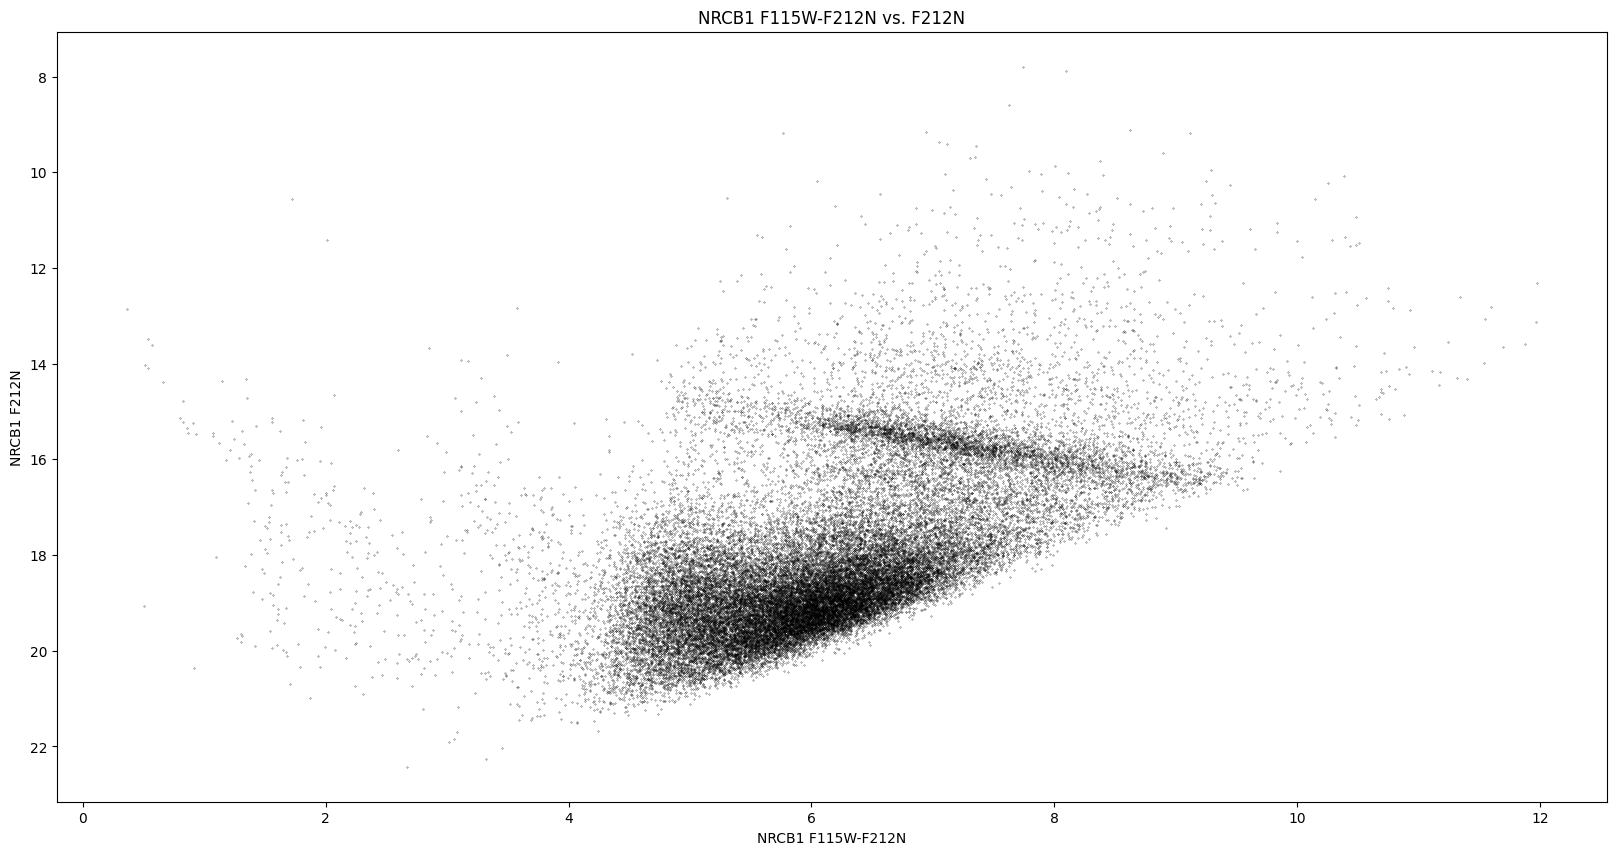

In [4]:
fig, axis = plt.subplots(1,1, figsize = (20, 10))

plt.scatter(np.subtract(N1_f115w_vf212n, N1_f212n_vf115w), N1_f212n_vf115w, c = 'k', s = 0.05)
plt.gca().invert_yaxis()
plt.xlabel('NRCB1 F115W-F212N')
plt.ylabel('NRCB1 F212N')
plt.title('NRCB1 F115W-F212N vs. F212N')

In [17]:
def cutoff(filt1, filt2, filty, cutoff): 
    # extract stars within rectangular cutoff 
    # in a filt1-filt2 vs. filty CMD

    # cutoff: [lower_left_x, lower_left_y, width, height]

    x = np.subtract(filt1, filt2) 
    y = filt2

    mag_idxs = [] 
    # will store indices of stars inside cutoff

    x_cutoff = []
    y_cutoff = []
    # will store mag values of stars inside cutoff

    for i in range(len(x)): 
        if x[i] >= cutoff[0] and x[i] < cutoff[0] + cutoff[2]: 
            if y[i] >= cutoff[1] and y[i] < cutoff[1] + cutoff[3]: 
                mag_idxs.append(i)

    for i in mag_idxs: 
        x_cutoff.append(x[i])
        y_cutoff.append(y[i])

    return mag_idxs, x_cutoff, y_cutoff

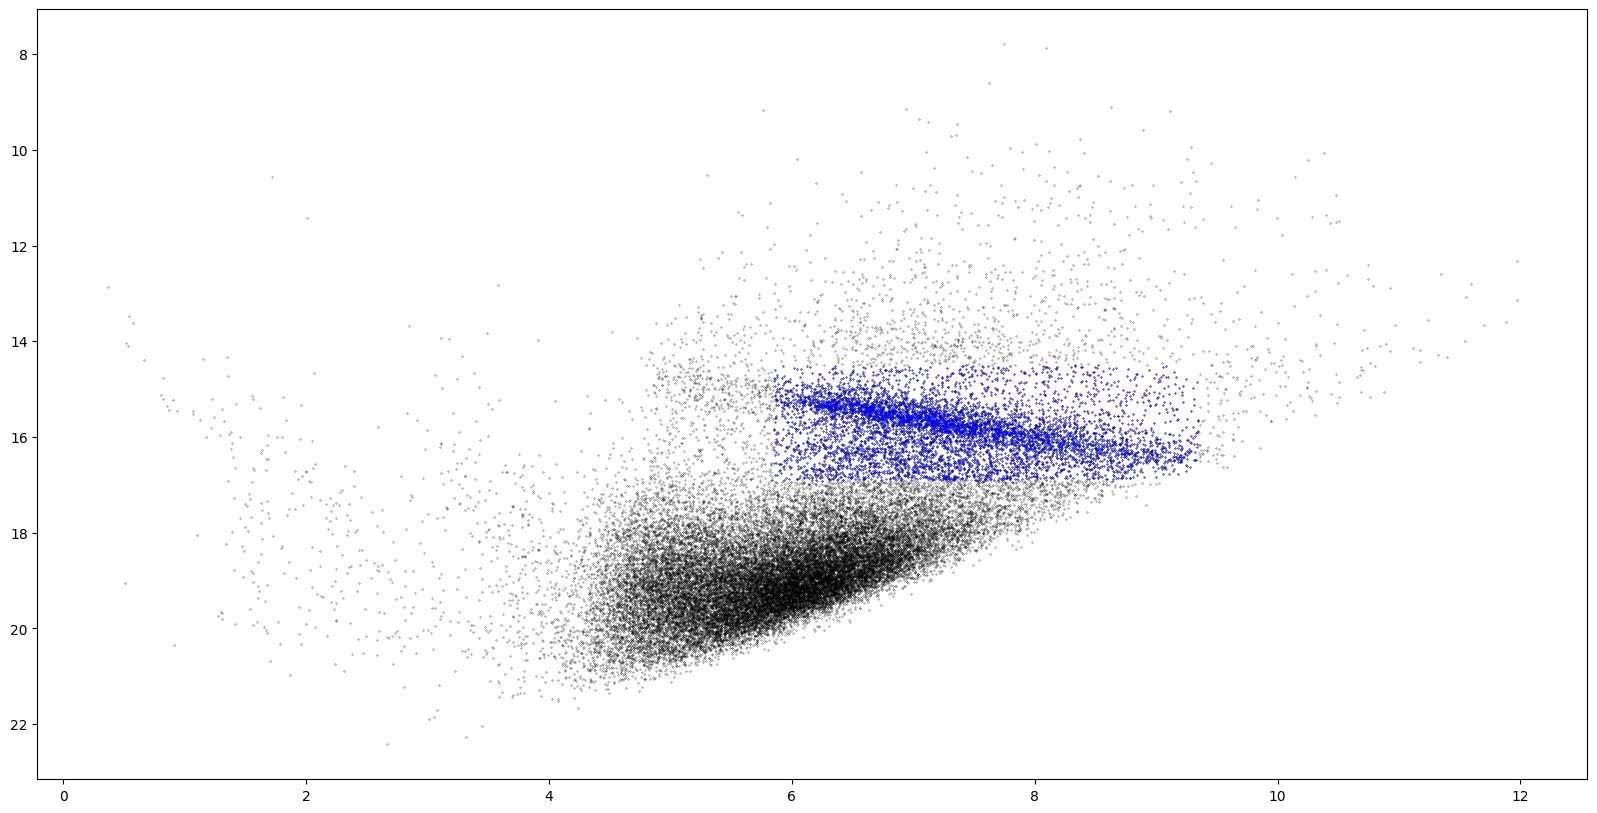

In [18]:
mag_idxs, x, y = cutoff(N1_f115w_vf212n, N1_f212n_vf115w, N1_f212n_vf115w, [5.85, 14.5, 3.5, 2.4])

fig, axis = plt.subplots(1, 1, figsize = (20, 10))
plt.gca().invert_yaxis()

plt.scatter(np.subtract(N1_f115w_vf212n, N1_f212n_vf115w), N1_f212n_vf115w, c = 'k', s = 0.05)
plt.scatter(x, y, c = 'b', s = 0.1)

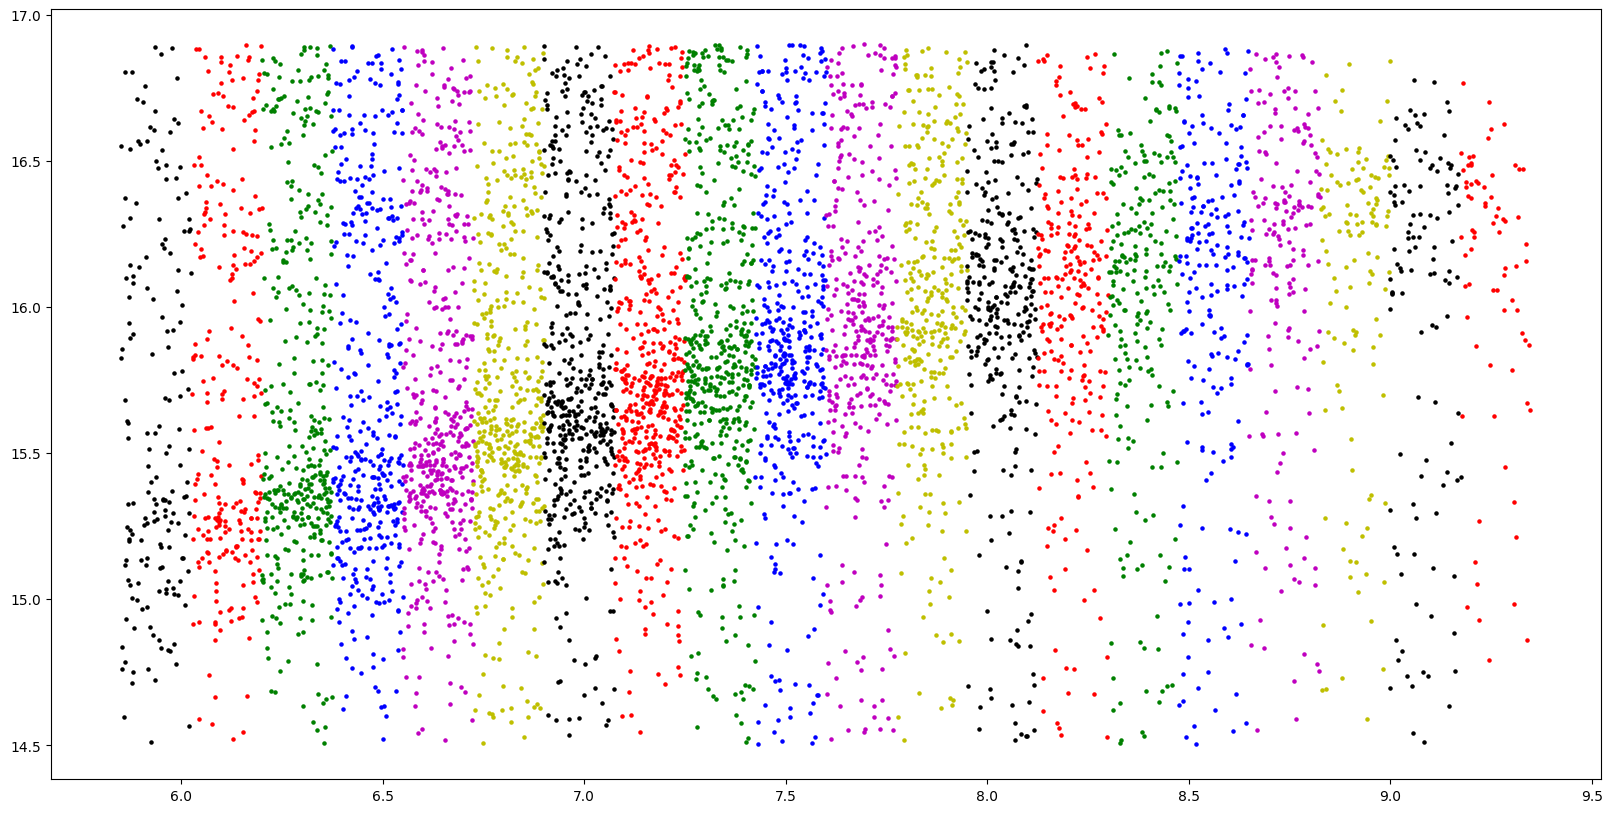

In [112]:
def define_bins(filt1, filt2, filty, cutoff, n): 
    x = cutoff[0]
    y = cutoff[1]
    dx = cutoff[2]/n

    filtx = np.subtract(filt1, filt2)
    
    bin_width = cutoff[3] / n
    
    xbins = []
    star_idx_bins = [] 
    # indices of each star in bins

    for i in range(n): 
        xbins.append([x + i * dx, x + i * dx + dx])

    idxs = []
    for i in range(len(xbins)): 
        for j in range(len(filtx)): 
            if filtx[j] >= xbins[i][0] and filtx[j] < xbins[i][1]: 
                if filty[j] >= cutoff[1] and filty[j] < cutoff[1] + cutoff[3]: 
                    idxs.append(j)
        star_idx_bins.append([idxs])
        idxs = []

        #goodx_lower = np.where(filtx >= xbins[i][0])
        #goodx_upper = np.where(filtx < xbins[i][1])
        #goody_lower = np.where(filty >= cutoff[1])
        #goody_upper = np.where(filty < cutoff[1] + cutoff[3])
        #good_x = np.intersect1d(goodx_lower, goodx_upper)
        #good_y = np.intersect1d(goody_lower, goody_upper)
        #good = np.intersect1d(good_x, good_y) 
        #star_idx_bins.append([good])

    filt1f = []
    filt2f = [] 

    for i in range(len(star_idx_bins)): 
        for j in star_idx_bins[i]: 
            filt1f.append(filtx[j])
            filt2f.append(filty[j])

    fig, axis = plt.subplots(1, 1, figsize = (20, 10))
    colors = ['k','r','g','b','m','y']

    for i in range(n):
        color = colors[i % len(colors)]
        plt.scatter(filt1f[i], filt2f[i], s = 5, c = color)
    

    return filt1f, filt2f
            

filt1f, filt2f = define_bins(N1_f115w_vf212n, N1_f212n_vf115w, N1_f212n_vf115w, [5.85, 14.5, 3.5, 2.4], 20)

(15.634015195330685, 0.6221700869354831)
Model: CompoundModel
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Expression: [0] + [1]
Components: 
    [0]: <Gaussian1D(amplitude=39.69606759, mean=15.20690708, stddev=0.06275411)>

    [1]: <Linear1D(slope=2.93851322, intercept=-19.68078563)>
Parameters:
       amplitude_0    ...
    ----------------- ...
    39.69606759127267 ...
(15.726892705415551, 0.62103069263283)
Model: CompoundModel
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Expression: [0] + [1]
Components: 
    [0]: <Gaussian1D(amplitude=114.82989771, mean=15.38684355, stddev=0.14046852)>

    [1]: <Linear1D(slope=11.96792243, intercept=-152.24331205)>
Parameters:
       amplitude_0     ...
    ------------------ ...
    114.82989770932659 ...
(15.68594345546327, 0.5984301007310003)
Model: CompoundModel
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Expression: [0] + [1]
Components: 
    [0]: <Gaussian1D(amplitude=148.15180101, mean=15.32302995, stddev=0.18021262)>

    [

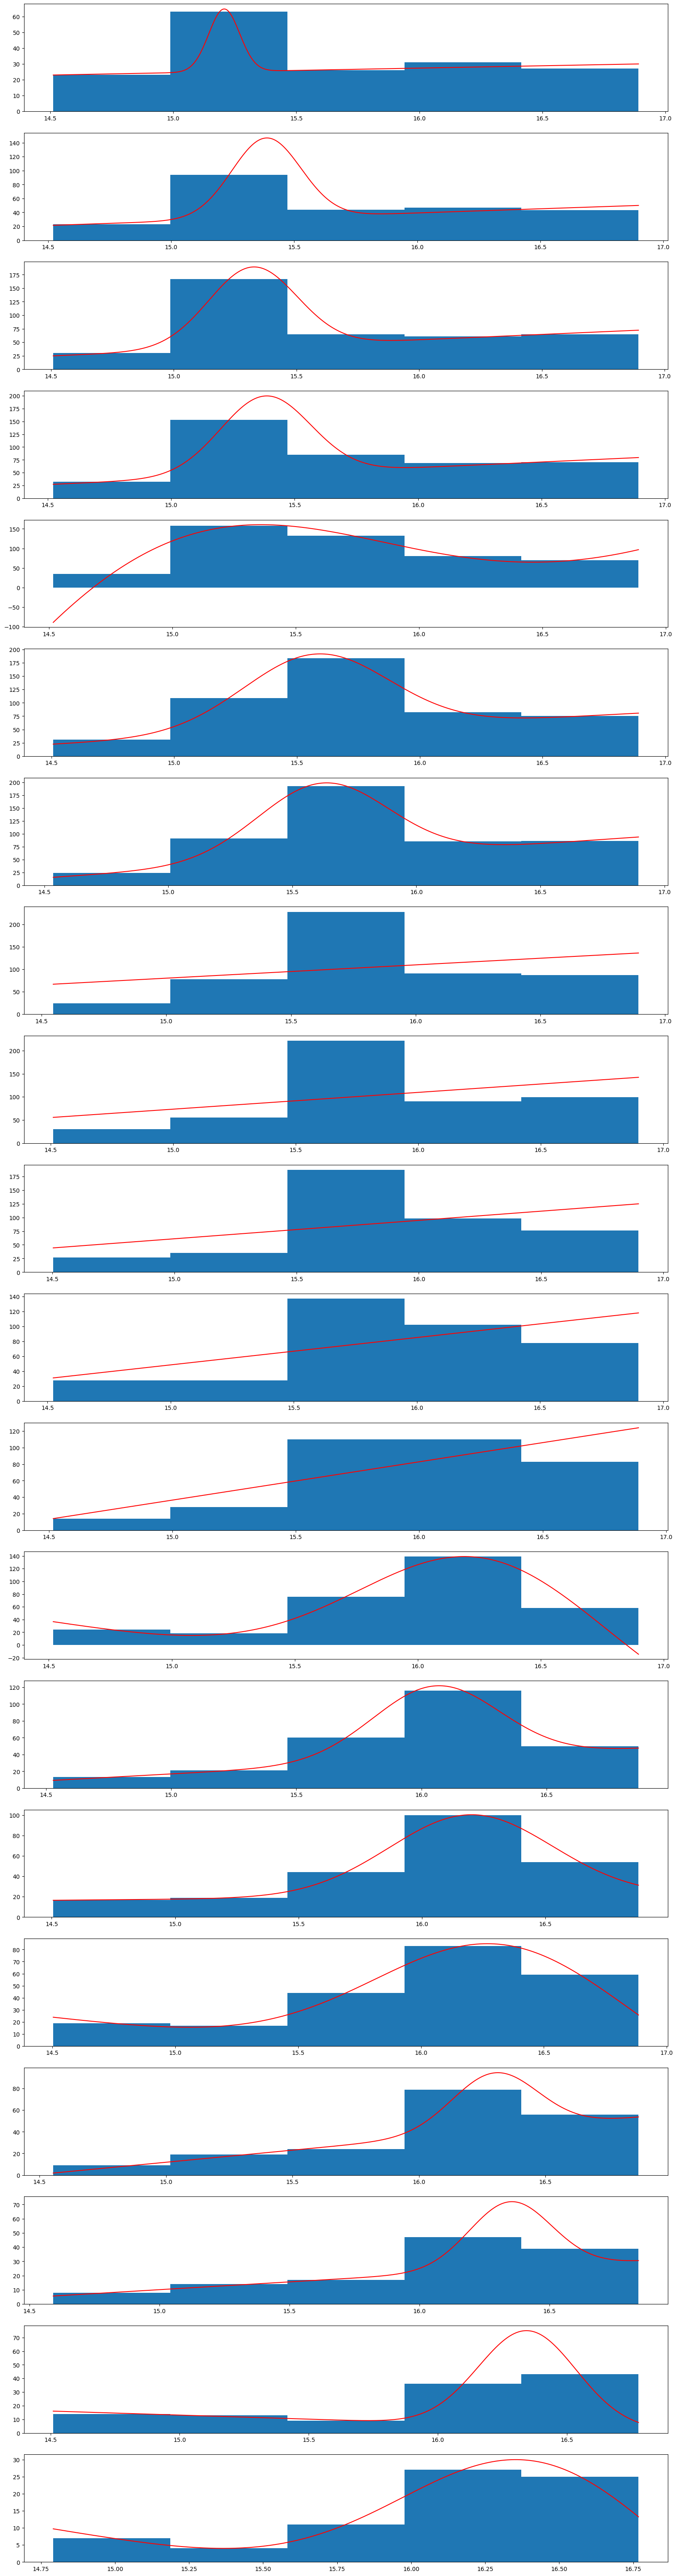

In [115]:
from scipy.stats import norm

def compound_hist(filt1f, filt2f, n): 
    fig, axis = plt.subplots(n, 1, figsize = (20, 80))
    
    for i in range(n): 
        bin_heights, bin_borders = np.histogram(filt2f[i], bins=5)
        bin_widths = np.diff(bin_borders)
        bin_centers = bin_borders[:-1] + bin_widths / 2

        mu, std = norm.fit(filt2f[i]) 
        print(norm.fit(filt2f[i]))
        
        t_init = models.Gaussian1D(200, mu, std)
        t_init2 = models.Linear1D(100, 100)
        t_initf = t_init + t_init2
        
        fit_t = fitting.LevMarLSQFitter()
        t = fit_t(t_initf, bin_centers, bin_heights)
        
        x_interval_for_fit = np.linspace(bin_borders[0], bin_borders[-1], 10000)
        axis[i].bar(bin_centers, bin_heights, width=bin_widths, label='histogram')
        axis[i].plot(x_interval_for_fit, t(x_interval_for_fit), label='fit', c='red')
        print(t)

    return 
        
compound_hist(filt1f, filt2f, 20)